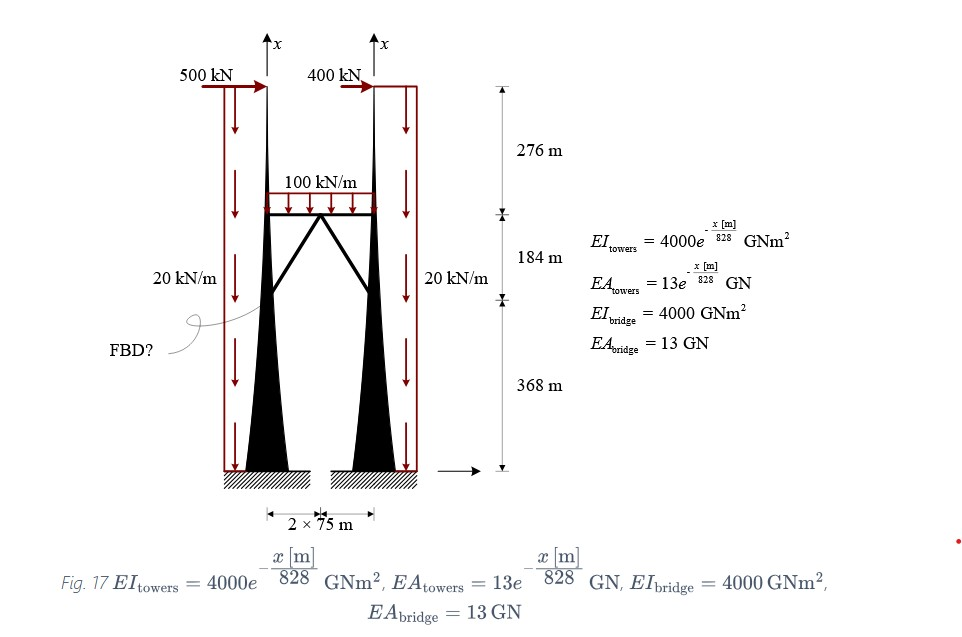

In [1]:
from IPython.display import Image, display
display(Image(filename='Screenshot 2026-04-17 100516.jpg'))

Free displacement vector u:
[ 7.45088811e-01  5.94695908e-01 -4.50005080e-03  1.47634676e+00
  7.89261769e-01 -3.09338107e-03  3.94268802e+00  9.24091877e-01
 -1.18573380e-02  1.39258195e+00  8.46252815e-01 -7.75570976e-04
  1.48253006e+00  1.10404096e+00 -2.23636280e-03  4.11547630e+00
  1.23887106e+00 -1.31913090e-02  1.47487213e+00  9.45656670e-01
 -1.83251632e-03]

Support reactions:
[ 6.39513918e+01 -9.63951392e+02 -2.05021150e+04 -2.76178850e+04
  2.73998895e+04  1.84117368e+05]


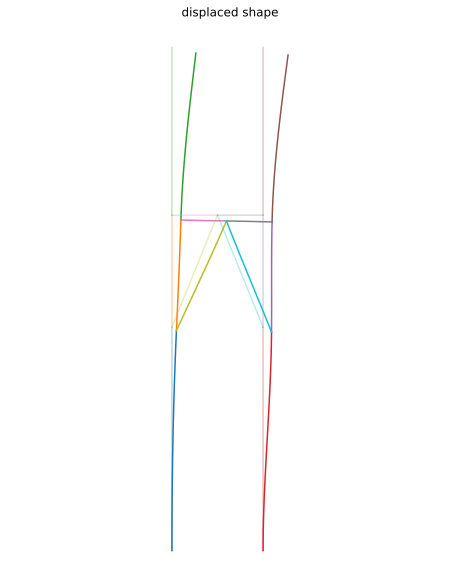

In [ ]:
import numpy as np
import matrixmethod as mm
import matplotlib.pyplot as plt

%config InlineBackend.figure_formats = ['svg']
%load_ext autoreload
%autoreload 2

mm.Node.clear()
mm.Element.clear()


GN_to_kN = 1e6
GNm2_to_kNm2 = 1e6

def EI_tower(x):
    return 4000.0 * np.exp(-x / 828.0) * GNm2_to_kNm2

def EA_tower(x):
    return 13.0 * np.exp(-x / 828.0) * GN_to_kN

EI_bridge = 4000.0 * GNm2_to_kNm2
EA_bridge = 13.0 * GN_to_kN


# loads
q_tower = -20.0     # distributed load on towers (negative means downward)
q_bridge = 100.0   # distributed load on bridge

Fx_left_top = 400.0
Fx_right_top = 500.0


# geometry
tower_height = 828.0

y_left = 0.0
y_right = 150.0
y_mid = 75.0

x_base = 0.0
x_low = 368.0
x_bridge = 552.0
x_top = 828.0

def tower_plot_z(x):
    return tower_height - x


# required nodes
left_base = mm.Node(y_left, tower_plot_z(x_base))
left_low_node = mm.Node(y_left, tower_plot_z(x_low))
left_bridge_node = mm.Node(y_left, tower_plot_z(x_bridge))
left_top = mm.Node(y_left, tower_plot_z(x_top))

right_base = mm.Node(y_right, tower_plot_z(x_base))
right_low_node = mm.Node(y_right, tower_plot_z(x_low))
right_bridge_node = mm.Node(y_right, tower_plot_z(x_bridge))
right_top = mm.Node(y_right, tower_plot_z(x_top))

mid_bridge_node = mm.Node(y_mid, tower_plot_z(x_bridge))

nodes = [
    left_base, left_low_node, left_bridge_node, left_top,
    right_base, right_low_node, right_bridge_node, right_top,
    mid_bridge_node
]


# elements
elems = []


# left tower
left_tower_segments = [
    (left_base, left_low_node, x_base, x_low),
    (left_low_node, left_bridge_node, x_low, x_bridge),
    (left_bridge_node, left_top, x_bridge, x_top),
]

left_tower_elems = []
for n1, n2, x1, x2 in left_tower_segments:
    e = mm.Element(n1, n2)
    xmid = 0.5 * (x1 + x2)
    e.set_section({
        'EI': EI_tower(xmid),
        'EA': EA_tower(xmid)
    })
    left_tower_elems.append(e)
    elems.append(e)


# right tower
right_tower_segments = [
    (right_base, right_low_node, x_base, x_low),
    (right_low_node, right_bridge_node, x_low, x_bridge),
    (right_bridge_node, right_top, x_bridge, x_top),
]

right_tower_elems = []
for n1, n2, x1, x2 in right_tower_segments:
    e = mm.Element(n1, n2)
    xmid = 0.5 * (x1 + x2)
    e.set_section({
        'EI': EI_tower(xmid),
        'EA': EA_tower(xmid)
    })
    right_tower_elems.append(e)
    elems.append(e)


# bridge
e_bridge_left = mm.Element(left_bridge_node, mid_bridge_node)
e_bridge_right = mm.Element(mid_bridge_node, right_bridge_node)

e_bridge_left.set_section({
    'EI': EI_bridge,
    'EA': EA_bridge
})
e_bridge_right.set_section({
    'EI': EI_bridge,
    'EA': EA_bridge
})

elems.append(e_bridge_left)
elems.append(e_bridge_right)


# diagonals
e_diag_left = mm.Element(left_low_node, mid_bridge_node)
e_diag_right = mm.Element(mid_bridge_node, right_low_node)

e_diag_left.set_section({
    'EI': EI_bridge,
    'EA': EA_bridge
})
e_diag_right.set_section({
    'EI': EI_bridge,
    'EA': EA_bridge
})

elems.append(e_diag_left)
elems.append(e_diag_right)


# loads applying
# top horizontal point loads
left_top.add_load([Fx_left_top, 0.0, 0.0])
right_top.add_load([Fx_right_top, 0.0, 0.0])

# distributed load on bridge
e_bridge_left.add_distributed_load([0.0, q_bridge])
e_bridge_right.add_distributed_load([0.0, q_bridge])

# distributed load on tower elements
for e in left_tower_elems + right_tower_elems:
    e.add_distributed_load([q_tower, 0.0])

# supports
# both tower bases fixed
con = mm.Constrainer()

for dof in [0, 1, 2]:
    con.fix_dof(left_base, dof)
    con.fix_dof(right_base, dof)


# global system
ndof = 3 * len(nodes)
global_k = np.zeros((ndof, ndof))
global_f = np.zeros(ndof)

for e in elems:
    elmat = e.stiffness()
    idofs = e.global_dofs()
    global_k[np.ix_(idofs, idofs)] += elmat

for n in nodes:
    global_f[n.dofs] += n.p


# solve
Kff, Ff = con.constrain(global_k, global_f)
u = np.linalg.solve(Kff, Ff)
u_full = con.full_disp(u)

print("Free displacement vector u:")
print(u)

print("\nSupport reactions:")
print(con.support_reactions(global_k, u, global_f))


# plot
plt.figure(figsize=(8, 10))

for e in elems:
    u_elem = u_full[e.global_dofs()]
    e.plot_displaced(u_elem, num_points=51, global_c=True, scale=10)

plt.axis('equal')
plt.grid(True)
plt.title("displaced shape")
plt.show()

In [3]:
# ------------------------------------------------------------
# nodal displacement table
# ------------------------------------------------------------
node_table = []

for i, n in enumerate(nodes, start=1):
    ux = u_full[n.dofs[0]]
    uy = u_full[n.dofs[1]]
    rz = u_full[n.dofs[2]]
    node_table.append([i, ux, uy, rz])

import pandas as pd
df_disp = pd.DataFrame(node_table, columns=["Node", "u_x [m]", "u_y [m]", "theta_z [rad]"])
print(df_disp)

   Node   u_x [m]   u_y [m]  theta_z [rad]
0     1  0.000000  0.000000       0.000000
1     2  0.745089  0.594696      -0.004500
2     3  1.476347  0.789262      -0.003093
3     4  3.942688  0.924092      -0.011857
4     5  0.000000  0.000000       0.000000
5     6  1.392582  0.846253      -0.000776
6     7  1.482530  1.104041      -0.002236
7     8  4.115476  1.238871      -0.013191
8     9  1.474872  0.945657      -0.001833


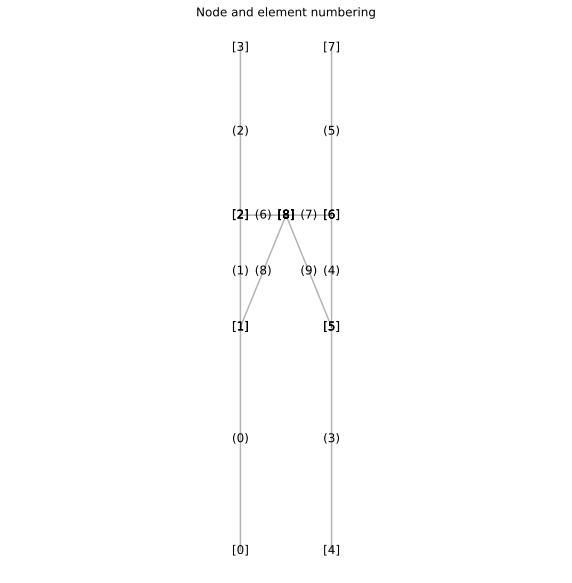

   Node    ux [m]    uy [m]  rz [rad]
0     0  0.000000  0.000000  0.000000
1     1  0.745089  0.594696 -0.004500
2     2  1.476347  0.789262 -0.003093
3     3  3.942688  0.924092 -0.011857
4     4  0.000000  0.000000  0.000000
5     5  1.392582  0.846253 -0.000776
6     6  1.482530  1.104041 -0.002236
7     7  4.115476  1.238871 -0.013191
8     8  1.474872  0.945657 -0.001833

Rounded nodal displacement table:
 Node       ux [m]       uy [m]      rz [rad]
    0 0.000000e+00 0.000000e+00  0.000000e+00
    1 7.450888e-01 5.946959e-01 -4.500051e-03
    2 1.476347e+00 7.892618e-01 -3.093381e-03
    3 3.942688e+00 9.240919e-01 -1.185734e-02
    4 0.000000e+00 0.000000e+00  0.000000e+00
    5 1.392582e+00 8.462528e-01 -7.755710e-04
    6 1.482530e+00 1.104041e+00 -2.236363e-03
    7 4.115476e+00 1.238871e+00 -1.319131e-02
    8 1.474872e+00 9.456567e-01 -1.832516e-03


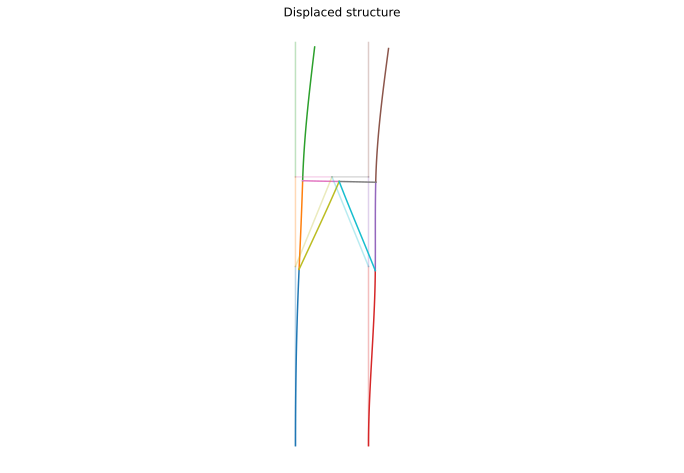

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# 1) FIGURE: node and element numbering
# ============================================================
plt.figure(figsize=(10, 10))

elements_number = np.arange(len(elems))
for elem, elem_nr in zip(elems, elements_number):
    elem.plot_numbered_structure(elem_nr)

plt.axis('equal')
plt.grid(True)
plt.title("Node and element numbering")
plt.savefig("nodes_elements_defining.png", facecolor="white", bbox_inches="tight")
plt.show()

# ============================================================
# 2) TABLE: all nodal displacements
# ============================================================
node_rows = []

for i, n in enumerate(nodes):
    node_rows.append({
        "Node": i,
        "ux [m]": u_full[n.dofs[0]],
        "uy [m]": u_full[n.dofs[1]],
        "rz [rad]": u_full[n.dofs[2]],
    })

df_nodes = pd.DataFrame(node_rows)
print(df_nodes)

# optional: nicer formatting
df_nodes_round = df_nodes.copy()
df_nodes_round["ux [m]"] = df_nodes_round["ux [m]"].map(lambda x: f"{x:.6e}")
df_nodes_round["uy [m]"] = df_nodes_round["uy [m]"].map(lambda x: f"{x:.6e}")
df_nodes_round["rz [rad]"] = df_nodes_round["rz [rad]"].map(lambda x: f"{x:.6e}")

print("\nRounded nodal displacement table:")
print(df_nodes_round.to_string(index=False))

# optional: save to csv
df_nodes.to_csv("nodal_displacements.csv", index=False)

# ============================================================
# 3) FIGURE: displaced structure
# ============================================================
plt.figure(figsize=(12, 8))

for e in elems:
    u_elem = u_full[e.global_dofs()]
    e.plot_displaced(u_elem, num_points=51, global_c=True, scale=10)

plt.axis('equal')
plt.grid(True)
plt.title("Displaced structure")
plt.savefig("displaced_structure.png", facecolor="white", bbox_inches="tight")
plt.show()

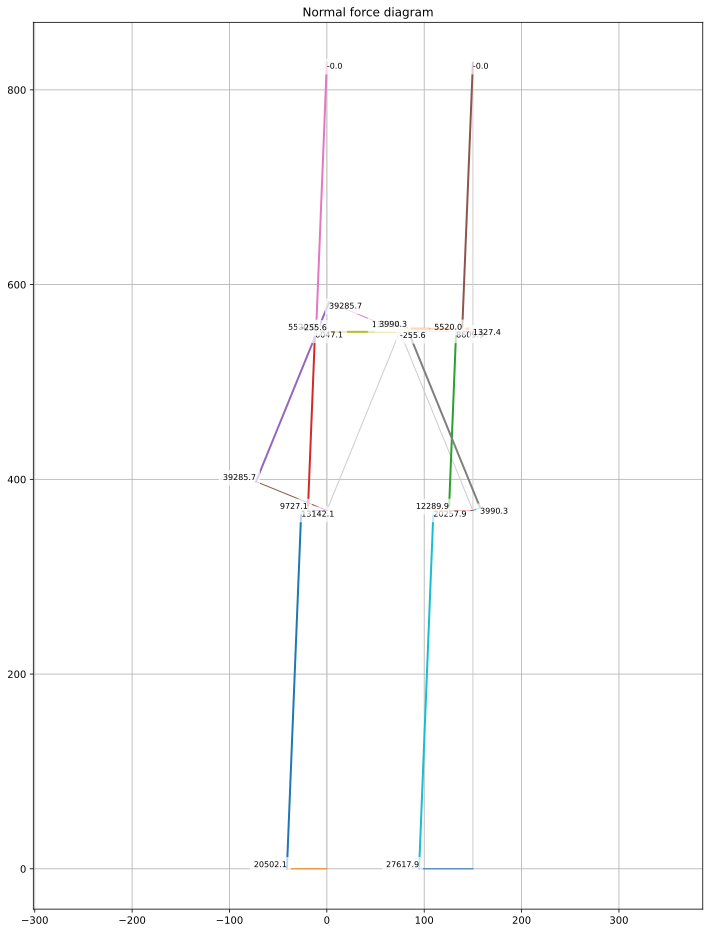

   Element Label  N_start [kN]    N_end [kN]
0        1    L1  20502.115049  1.314212e+04
1        2    L2   9727.102025  6.047102e+03
2        3    L3   5520.000000 -1.455192e-11
3        4    R1  27617.884951  2.025788e+04
4        5    R2  12289.938871  8.609939e+03
5        6    R3   5520.000000 -5.456968e-12
6        7    B1   -255.602803 -2.556028e+02
7        8    B2   1327.375027  1.327375e+03
8        9    D1  39285.653354  3.928565e+04
9       10    D2   3990.301479  3.990301e+03


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 4) FIGURE: normal force diagram
# ============================================================
plt.close('all')
fig, ax = plt.subplots(figsize=(12, 16))

# ---- helper: map node dofs -> structural coordinates ----
# plotting coordinates:
# horizontal = tower y-position
# vertical   = structural height x
dof_to_xy = {
    tuple(left_base.dofs):         (y_left, 0.0),
    tuple(left_low_node.dofs):     (y_left, x_low),
    tuple(left_bridge_node.dofs):  (y_left, x_bridge),
    tuple(left_top.dofs):          (y_left, tower_height),

    tuple(right_base.dofs):        (y_right, 0.0),
    tuple(right_low_node.dofs):    (y_right, x_low),
    tuple(right_bridge_node.dofs): (y_right, x_bridge),
    tuple(right_top.dofs):         (y_right, tower_height),

    tuple(mid_bridge_node.dofs):   (y_mid, x_bridge),
}

# ---- helper: local geometry and local axial displacements ----
def get_element_geometry(elem):
    idofs = elem.global_dofs()
    dofs1 = tuple(idofs[:3])
    dofs2 = tuple(idofs[3:6])

    x1, y1 = dof_to_xy[dofs1]
    x2, y2 = dof_to_xy[dofs2]

    dx = x2 - x1
    dy = y2 - y1
    L = np.sqrt(dx**2 + dy**2)

    c = dx / L
    s = dy / L

    return idofs, x1, y1, x2, y2, L, c, s

def get_normal_force_end_values(elem, EA, qx=0.0):
    """
    Returns normal force at element start and end.

    Sign convention:
    positive = tension, same convention as your old N formula.
    qx is the distributed load in the element LOCAL x-direction.
    """
    idofs, x1, y1, x2, y2, L, c, s = get_element_geometry(elem)
    u_elem = u_full[idofs]

    # local axial displacements at node 1 and node 2
    u1_local = c * u_elem[0] + s * u_elem[1]
    u2_local = c * u_elem[3] + s * u_elem[4]

    # constant axial force contribution from displacement field
    N_def = (EA / L) * (u2_local - u1_local)

    # add variation from uniform distributed axial load qx
    N_start = N_def - qx * L / 2.0
    N_end   = N_def + qx * L / 2.0

    return N_start, N_end, x1, y1, x2, y2, L, c, s

# ---- collect data for all elements ----
element_force_data = []

# left tower: qx = q_tower
left_tower_data = [
    (left_tower_elems[0], EA_tower(0.5 * (0.0 + x_low)), q_tower, "L1"),
    (left_tower_elems[1], EA_tower(0.5 * (x_low + x_bridge)), q_tower, "L2"),
    (left_tower_elems[2], EA_tower(0.5 * (x_bridge + tower_height)), q_tower, "L3"),
]

# right tower: qx = q_tower
right_tower_data = [
    (right_tower_elems[0], EA_tower(0.5 * (0.0 + x_low)), q_tower, "R1"),
    (right_tower_elems[1], EA_tower(0.5 * (x_low + x_bridge)), q_tower, "R2"),
    (right_tower_elems[2], EA_tower(0.5 * (x_bridge + tower_height)), q_tower, "R3"),
]

# bridge + diagonals: no distributed axial load
other_data = [
    (e_bridge_left, EA_bridge, 0.0, "B1"),
    (e_bridge_right, EA_bridge, 0.0, "B2"),
    (e_diag_left, EA_bridge, 0.0, "D1"),
    (e_diag_right, EA_bridge, 0.0, "D2"),
]

element_force_data.extend(left_tower_data)
element_force_data.extend(right_tower_data)
element_force_data.extend(other_data)

# ---- choose plot scale ----
N_scale = 0.002

# ---- plot undeformed structure in light gray ----
for e in elems:
    _, x1, y1, x2, y2, _, _, _ = get_element_geometry(e)
    ax.plot([x1, x2], [y1, y2], color='0.8', linewidth=1)

# ---- plot normal force diagram ----
rows = []

for i, (e, EA, qx, label) in enumerate(element_force_data, start=1):
    N1, N2, x1, y1, x2, y2, L, c, s = get_normal_force_end_values(e, EA, qx=qx)

    # unit normal to element axis
    nx = -s
    ny = c

    # offset at both ends
    off1 = N_scale * N1
    off2 = N_scale * N2

    x1n = x1 + nx * off1
    y1n = y1 + ny * off1
    x2n = x2 + nx * off2
    y2n = y2 + ny * off2

    # main normal-force line
    ax.plot([x1n, x2n], [y1n, y2n], linewidth=2)

    # connectors
    ax.plot([x1, x1n], [y1, y1n], linewidth=1)
    ax.plot([x2, x2n], [y2, y2n], linewidth=1)

    # labels at both ends
    ax.text(
        x1n, y1n, f"{N1:.1f}",
        fontsize=8, ha='right', va='bottom',
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.7)
    )
    ax.text(
        x2n, y2n, f"{N2:.1f}",
        fontsize=8, ha='left', va='top',
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.7)
    )

    rows.append([i, label, N1, N2])

ax.axis('equal')
ax.grid(True)
ax.set_title("Normal force diagram")
plt.savefig("normal_force_diagram.png", dpi=300, facecolor='white', bbox_inches='tight')
plt.show()

df_N = pd.DataFrame(rows, columns=["Element", "Label", "N_start [kN]", "N_end [kN]"])
print(df_N)

In [6]:
# full reaction vector
R = global_k @ u_full - global_f

# dofs at supports
left_dofs = left_base.dofs
right_dofs = right_base.dofs

print("Left support reactions:")
print(f"Rx = {R[left_dofs[0]]:.3f} kN")
print(f"Ry = {R[left_dofs[1]]:.3f} kN")
print(f"Mz = {R[left_dofs[2]]:.3f} kNm")

print("\nRight support reactions:")
print(f"Rx = {R[right_dofs[0]]:.3f} kN")
print(f"Ry = {R[right_dofs[1]]:.3f} kN")
print(f"Mz = {R[right_dofs[2]]:.3f} kNm")

Left support reactions:
Rx = 63.951 kN
Ry = -20502.115 kN
Mz = 27399.889 kNm

Right support reactions:
Rx = -963.951 kN
Ry = -27617.885 kN
Mz = 184117.368 kNm


In [7]:
# ============================================================
# JOINT FREE-BODY DIAGRAM OF A NODE
# decomposed per element
# ============================================================
import numpy as np
import pandas as pd

target = 1
target_dofs = list(nodes[target].dofs)

def element_equivalent_load_global(e):
    """
    Equivalent nodal load vector in global coordinates caused by the
    distributed load assigned to element e.
    """
    if not hasattr(e, "q"):
        return np.zeros(6)

    q = np.array(e.q, dtype=float)
    L = e.L

    local_element_load = np.array([
        0.5 * q[0] * L,
        0.5 * q[1] * L,
        -1.0 / 12.0 * q[1] * L * L,
        0.5 * q[0] * L,
        0.5 * q[1] * L,
        1.0 / 12.0 * q[1] * L * L
    ])

    return e.Tt @ local_element_load

print(f"Node {target} DOFs: {nodes[target].dofs}")
print()

rows = []
sum_internal = np.zeros(3)
sum_equiv_load = np.zeros(3)

for i, e in enumerate(elems):
    edofs = list(e.global_dofs())
    ke = e.stiffness()
    ue = u_full[edofs]

    # deformation-based end action vector
    fe_def = ke @ ue

    # equivalent nodal load vector from element distributed load
    fe_load = element_equivalent_load_global(e)

    if edofs[:3] == target_dofs:
        side = "first end"
        f_def = fe_def[:3].copy()
        f_load = fe_load[:3].copy()
    elif edofs[3:6] == target_dofs:
        side = "second end"
        f_def = fe_def[3:6].copy()
        f_load = fe_load[3:6].copy()
    else:
        continue

    # force of element on node:
    # internal resisting part minus equivalent load part
    # if your sign convention appears reversed, flip the sign of both
    f_total = f_def - f_load

    print(f"Element {i} ({side})")
    print(f"  deformation part     [Fx, Fy, Mz] = {f_def}")
    print(f"  dist-load equiv part [Fx, Fy, Mz] = {f_load}")
    print(f"  total force on node  [Fx, Fy, Mz] = {f_total}")
    print()

    rows.append([
        i, side,
        f_def[0], f_def[1], f_def[2],
        f_load[0], f_load[1], f_load[2],
        f_total[0], f_total[1], f_total[2]
    ])

    sum_internal += f_def
    sum_equiv_load += f_load

print("--------------------------------------------------")
print("SUM over all connected elements at this node")
print("--------------------------------------------------")
print("Sum deformation parts:")
print("[Fx, Fy, Mz] =", sum_internal)

print("\nSum equivalent distributed-load parts:")
print("[Fx, Fy, Mz] =", sum_equiv_load)

print("\nSum total element forces on node:")
print("[Fx, Fy, Mz] =", sum_internal - sum_equiv_load)

print("\nAssembled nodal load stored in node object:")
print("[Fx, Fy, Mz] =", nodes[target].p)

print("\nCheck that assembled nodal load equals sum of element load contributions:")
print("[Fx, Fy, Mz] =", sum_equiv_load - nodes[target].p)

df_joint = pd.DataFrame(rows, columns=[
    "Element", "End",
    "Fx_def", "Fy_def", "Mz_def",
    "Fx_load", "Fy_load", "Mz_load",
    "Fx_total", "Fy_total", "Mz_total"
])

print()
print(df_joint)

Node 1 DOFs: [3, 4, 5]

Element 0 (second end)
  deformation part     [Fx, Fy, Mz] = [   -63.95139182  16822.11504933 -50934.00165358]
  dist-load equiv part [Fx, Fy, Mz] = [-2.25335011e-13  3.68000000e+03  0.00000000e+00]
  total force on node  [Fx, Fy, Mz] = [   -63.95139182  13142.11504933 -50934.00165358]

Element 1 (first end)
  deformation part     [Fx, Fy, Mz] = [ -144.39719686 -7887.10202512 -4260.70947164]
  dist-load equiv part [Fx, Fy, Mz] = [-1.12667506e-13  1.84000000e+03  0.00000000e+00]
  total force on node  [Fx, Fy, Mz] = [ -144.39719686 -9727.10202512 -4260.70947164]

Element 8 (first end)
  deformation part     [Fx, Fy, Mz] = [  208.34858868 -3415.01302421 55194.71112521]
  dist-load equiv part [Fx, Fy, Mz] = [0. 0. 0.]
  total force on node  [Fx, Fy, Mz] = [  208.34858868 -3415.01302421 55194.71112521]

--------------------------------------------------
SUM over all connected elements at this node
--------------------------------------------------
Sum deformation pa